# BIRSVD demo


In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import jax
import numpy as np
import astropy.io.fits as fits
import scipy.ndimage as ndimage

from birsvd import birsvd

rcParams['image.origin'] = 'lower'
rcParams['legend.frameon'] = False

## Demo data

The array shape is `(time, y, x)`.  The size is intentionally small so
that the notebook runs quickly on CPU.

In [2]:
cube = fits.open('../data/demo.fits')[0].data
nz, ny, nx = cube.shape

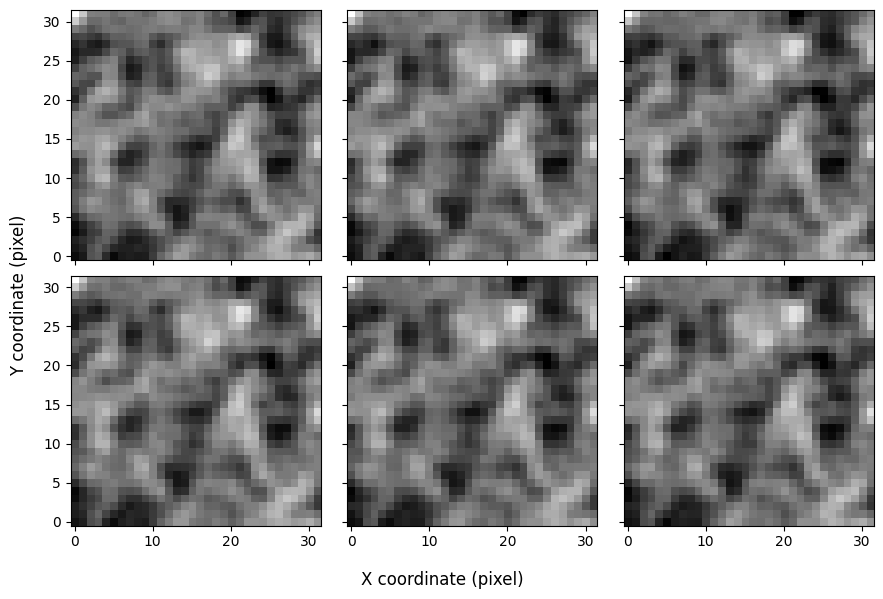

In [3]:
fig, axes = plt.subplots(
    2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
    ax.imshow(cube[n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit LinearBasisAE

The model learns detector-fixed basis images and frame-wise
coefficients.  Increase `inner_steps`, `outer_steps`, or
`latent_dim` for real data.


In [4]:
def robust_scale(x: np.array, min_scale: float) -> np.array:
    '''Estimate a robust residual scale with the median absolute deviation.'''

    median = np.median(x, axis=1, keepdims=True)
    mad = np.median(np.abs(x - median), axis=1, keepdims=True)
    return np.maximum(1.4826 * mad, min_scale)

In [5]:
data = cube.reshape(nz, ny * nx)
mask = np.ones_like(data)
n_rank = 2

result = birsvd(data, mask, n_rank)
res = result.residual(data)

In [6]:
scale = robust_scale(res, min_scale=1.0e-3)
mask = res > 2 * scale
kernel = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])

for n in range(nz):
    mask[n] = 1 - ndimage.binary_opening(mask[n].reshape(32, 32), kernel).ravel()

In [7]:
result = birsvd(data, mask, n_rank)
res = result.residual(data)

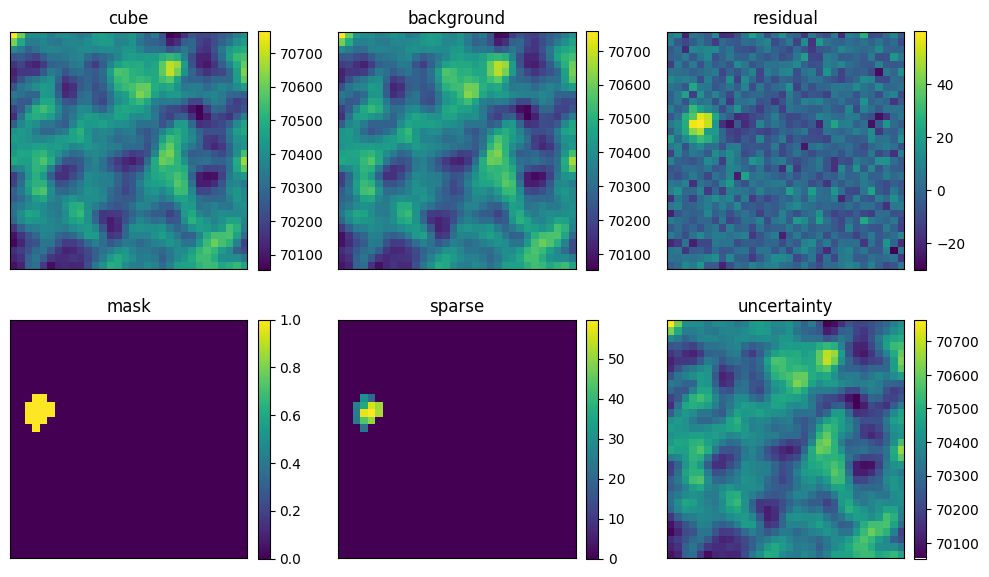

In [8]:
frame_index = 0
background = result.A.reshape(nz, ny, nx)
residual = res.reshape(nz, ny, nx)
maskcube = 1.0 - mask.reshape(nz, ny, nx)
sparse = maskcube * residual

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
    ('cube', cube[frame_index]),
    ('background', background[frame_index]),
    ('residual', residual[frame_index]),
    ('mask', maskcube[frame_index]),
    ('sparse', sparse[frame_index]),
    ('uncertainty', cube[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
    handle = axis.imshow(image, origin='lower', cmap='viridis')
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [9]:
hdul = fits.HDUList([
    fits.PrimaryHDU(data=residual),
    fits.ImageHDU(data=background, name='MODEL'),
    fits.ImageHDU(data=maskcube.astype('int16'), name='MASK'),
    fits.ImageHDU(data=sparse, name='SPARSE')
])
hdul.writeto('../data/birsvd.fits', overwrite=True)

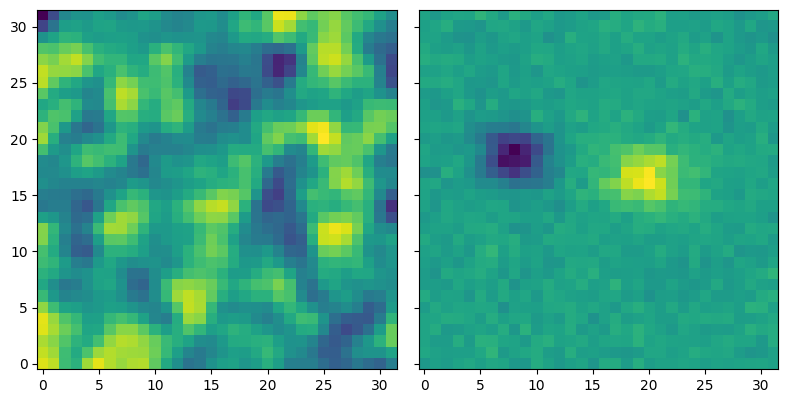

In [10]:
fig, axes = plt.subplots(
    1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(result.V[:, 0].reshape(ny, nx))
axes[1].imshow(result.V[:, 1].reshape(ny, nx))

fig.tight_layout()
plt.show()